# Data Analysis Task - Worked through example

This notebook explores anonymized monthly time series data. 

Examine the dataset using the information you have learnt in the Data Deep Dive lecture

Highlight interesting features about the dataset

Explain patterns of behaviour using your understanding about the economy and world events

Are there any issues with the dataset? How would you go about resolving them?

Make an educated guess about what the dataset could be (please don’t try and Google it! It spoils the fun and remember this task isn’t graded!)

In [3]:
# Import the required libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# read the csv data
df_data = pd.read_csv('anon_data.csv')
# format the date column 
df_data['Date'] = pd.to_datetime(df_data["Date"], format = "%d/%m/%Y")
# set and sort the date index 
df_data.set_index('Date', inplace=True)
df_data.sort_index(ascending=True, inplace=True)

# Preview the Data

Let us first print the data to get a sense of its structure and values

In [8]:
df_data

,Data
Date,
1945-01-01,1300
1945-02-01,1382
1945-03-01,1372
1945-04-01,1512
1945-05-01,1533
...,...
2024-08-01,9258
2024-09-01,8994
2024-10-01,9068


In [4]:
df_data.describe()

,Data
count,954.000000
mean,6557.928721
std,2293.186016
min,1300.000000
25%,4541.500000
50%,7040.000000
75%,8654.500000
max,9834.000000



The time series ranges from **1945** up to **2024**, and the `Data` column represents some anonymized data values observed monthly over this period.

Let’s plot the data over time to visualize its overall structure and identify any patterns

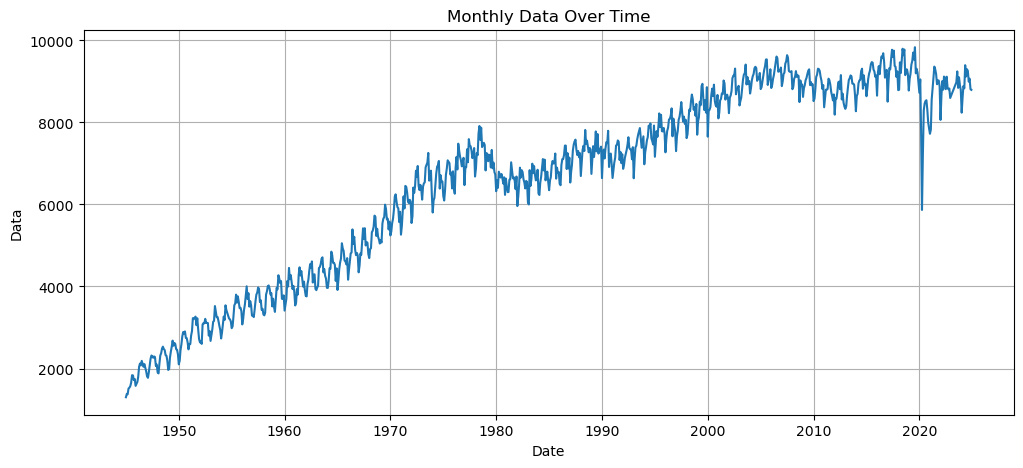

In [5]:
plt.figure(figsize=(12, 5))
plt.plot(df_data)
plt.title("Monthly Data Over Time")
plt.xlabel("Date")
plt.ylabel("Data")
plt.grid(True)
plt.show()

# Visualising the data

* Monthly frequency
* Long time series (back to before 1950!)
* Seasonal behaviour
* Trend upwards
* Downturns during economic crisis points

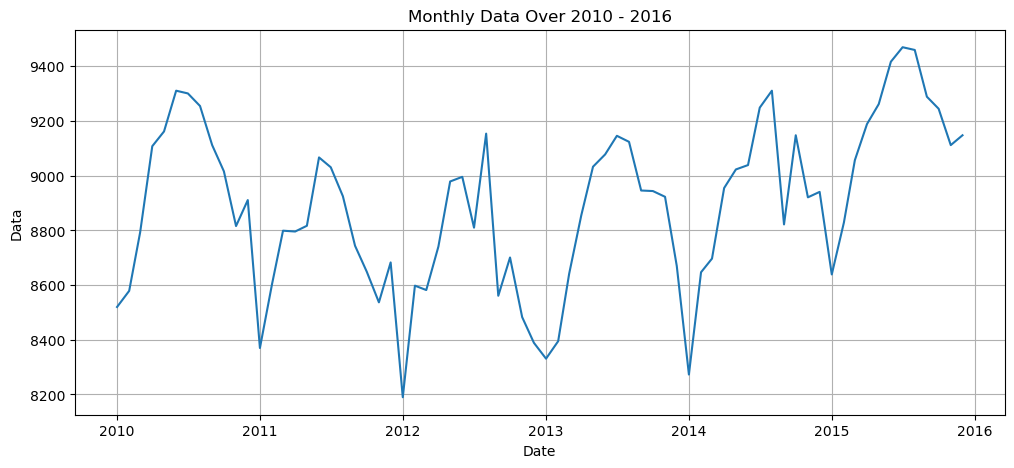

In [6]:
# lets look at the seasonal pattern in more detail
plt.figure(figsize=(12, 5))
plt.plot(df_data.loc['2010':'2015'])
plt.title("Monthly Data Over 2010 - 2016")
plt.xlabel("Date")
plt.ylabel("Data")
plt.grid(True)
plt.show()

# Seasonality
* Annual
* Peaks around middle of year
* Troughs around begging/end of year

# Data issues
The task specifically asked if there was any issues with the data set

Whilst the time series appears visually continuous, some data points are actually missing.  
This is because the plot connects each available point, even if there's a gap in the timeline.

We suspect there is a missing block of data, and in the next step, we'll investigate the dates more closely to identify **where** that gap occurs.

In [7]:
df_data["Month_Diff"] = df_data.index.to_series().diff() # find the difference between the dates
df_data[df_data["Month_Diff"] > pd.Timedelta(days=31)] # Check if there is a difference > 31 days

,Data,Month_Diff
Date,,
2023-07-01,8979,212 days


In [8]:
df_data.loc['2022':'2023']

,Data,Month_Diff
Date,,
2022-01-01,8062,31 days
2022-02-01,8650,31 days
2022-03-01,9005,28 days
2022-04-01,8799,31 days
2022-05-01,9119,30 days
2022-06-01,9075,31 days
2022-07-01,8812,30 days
2022-08-01,9115,31 days
2022-09-01,8847,31 days


As you can see, there is a significant gap of **212 days**, which breaks the expected monthly frequency of the data.

Let us now look where the gap starts and ends and how many months it lasts

In [9]:
month_after = df_data.index.to_series().diff().idxmax()

# Get the position of the index
pos = df_data.index.get_loc(month_after)

# Get the previous index
month_before = df_data.index[pos - 1]

# Get the month before and after the gap
print(f"The months before and after the gap are {month_before}, {month_after}")

The months before and after the gap are 2022-12-01 00:00:00, 2023-07-01 00:00:00


In [10]:
n_gap_months = (month_after.to_period("M") - month_before.to_period("M")).n - 1 # gaps in months
print(n_gap_months)

6


This gap ends at **2023-07-01**, meaning the missing period spans the **6 months leading up to that point**.

Next, we’ll use STL decomposition to analyze the trend and seasonality before this gap, and then use that information to estimate the missing values.


## What is STL Decomposition?

**STL (Seasonal-Trend decomposition using LOESS)** is a method for breaking down a time series into three additive components:

$$
P_t = S_t + T_t + R_t
$$

Where:
- $ P_t $ is the original data at time $ t $
- $ S_t $ is the **seasonal** component (repeating patterns)
- $ T_t $ is the **trend** component (long-term direction)
- $ R_t $ is the **residual** component (noise or irregular fluctuations)

This decomposition allows us to separately study the long-term behavior, seasonal effects, and randomness in the data — which is especially helpful when estimating missing values.

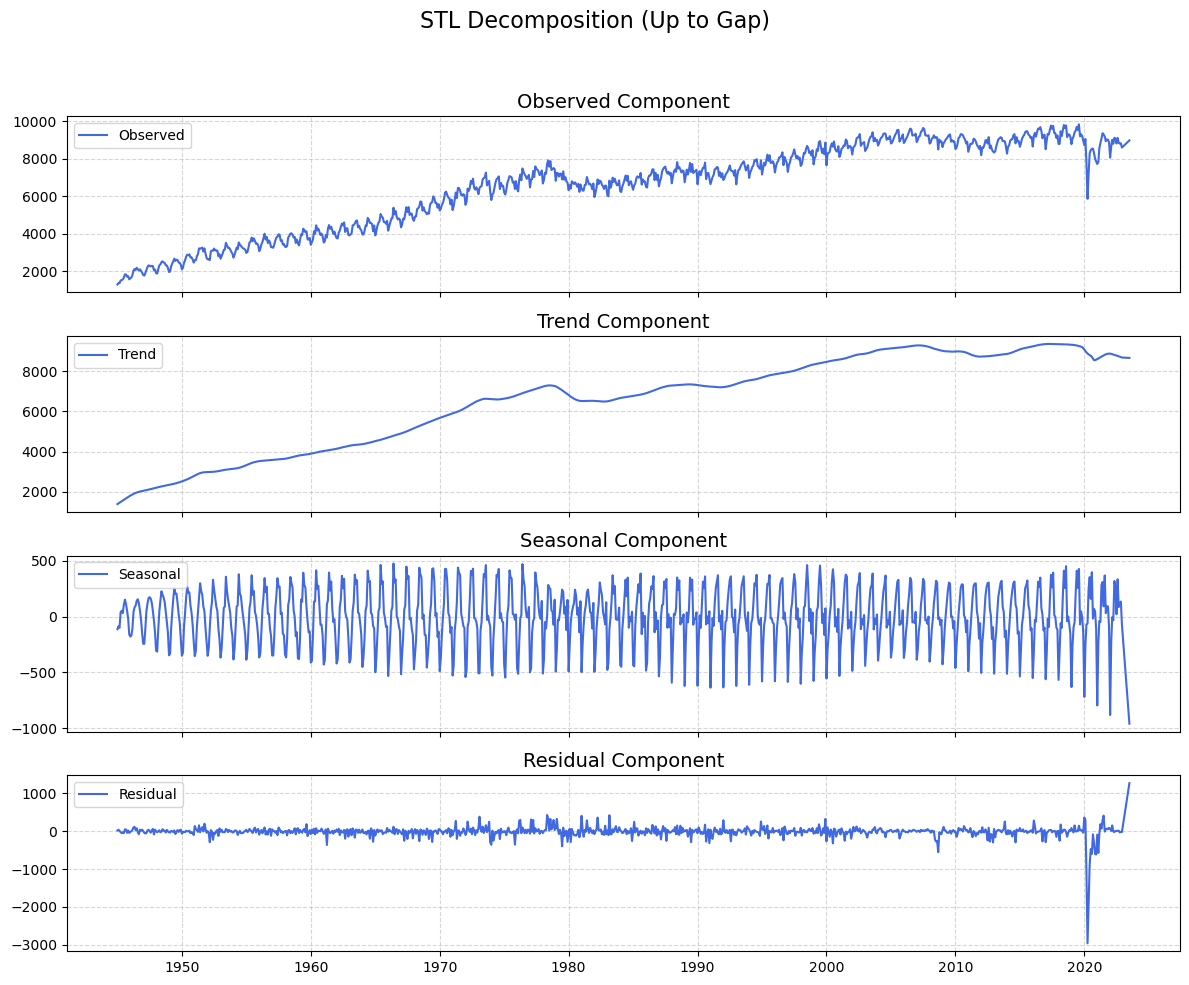

In [11]:
from statsmodels.tsa.seasonal import STL

# STEP 1: Identify where the gap begins
gap_idx = df_data.index.to_series().diff().idxmax()  # index of the first row *after* the gap

# STEP 2: Subset the data up to the gap (not inclusive of the gap)
data_series = df_data.loc[:gap_idx]['Data']

# STEP 3: Apply STL
stl = STL(data_series, period=12, robust=True)
result = stl.fit()

# STEP 4: Plot the components
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
components = ['Observed', 'Trend', 'Seasonal', 'Residual']
data = [result.observed, result.trend, result.seasonal, result.resid]

for ax, comp, series in zip(axes, components, data):
    ax.plot(series, label=comp, color='royalblue', linewidth=1.5)
    ax.set_title(f'{comp} Component', fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='best')

plt.suptitle('STL Decomposition (Up to Gap)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

After decomposing the time series using STL, we get four components

- **Observed**: the original data.
- **Trend**: a smooth curve showing the long-term direction of the data — it captures gradual increases and decreases over time.
- **Seasonal**: a repeating pattern that reflects regular monthly fluctuations — this appears more "jumpy" and cyclical.
- **Residual**: the leftover noise after removing trend and seasonality — this is mostly centered around zero, but shows a noticeable spike around **2020**

We will now try to impute the missing values. We need to figure the trend and the seasonal components to be able to reconstruct 
the missing values.

### Interpolating the trend
To guide our imputation, we take a brief look at the **trend values just before and after the missing period**.

While these two points alone aren’t enough to model the full shape of the missing data, they give us a useful indication of the **direction** and **magnitude** of change across the gap.

We'll use them to linearly interpolate the trend during the missing months.

In [12]:
trend_before = result.trend.iloc[-1]  # Last trend value before the gap
trend_after = df_data['Data'].loc[gap_idx]  # Placeholder: actual value after the gap
print(f"The trend before and after are {trend_before}, {trend_after}")

The trend before and after are 8666.332348586486, 8979


We will use `np.linspace()` to **linearly interpolate** between the trend value just before the gap and the one just after.

`np.linspace(start, end, n)` generates `n` evenly spaced values between `start` and `end`, inclusive.

In our case:
- `start` = trend before the gap  
- `end` = trend after the gap  
- `n` = number of months missing **plus two**, because we exclude the known endpoints

We’ll use this to create a smooth transition in trend across the gap.

In [13]:
# Interpolate trend values (excluding endpoints)
trend_interp = np.linspace(trend_before, trend_after, n_gap_months + 2)[1:-1]

### Estimating the Seasonal component 

To estimate the seasonal component during the missing period, we’ll reuse the **previous 12 months of seasonal values** from before the gap. This gives us a full seasonal cycle — capturing how the data typically behaves month-to-month across a year.

Since seasonality tends to repeat in regular intervals, this approach provides a **realistic estimate of the cyclical pattern** during the missing months.


To reconstruct the seasonal component across the missing period, we use the previous 12 months of seasonal values as a base pattern. Since the gap spans multiple months, we use `np.tile`

In [14]:
# Repeat seasonal pattern from last 12 months
seasonal_pattern = result.seasonal[-12:].values
seasonal_interp = np.tile(seasonal_pattern, int(np.ceil(n_gap_months / 12)))[:n_gap_months]


### 🔧 Reconstructing the Missing Values

We now reconstruct the missing data points by combining the **interpolated trend** and the **repeated seasonal pattern**:

$$
\hat{P}_t = T_t + S_t
$$

Where:
- $ \hat{P}_t $ is the reconstructed value at time $ t $
- $ T_t $ is the interpolated trend component
- $ S_t $ is the seasonal component from the prior 12-month cycle

We do **not include the residual component** in this reconstruction.  
Residuals capture random noise and irregular variations that are unpredictable and not part of the underlying structure of the data. Including them could add unrealistic or misleading fluctuations into the imputed values.

By using only the trend and seasonality, we aim to create a smooth and reasonable estimate of what the missing data likely looked like.

In [15]:
# Final reconstruction
reconstructed_values = trend_interp + seasonal_interp

We will now create a dataframe of the reconstructed values with the missing months

In [16]:
# Constructing the dataframe with the missing values
missing_months = pd.date_range(start=month_before + pd.DateOffset(months=1),
                               end=month_after - pd.DateOffset(months=1),
                               freq='MS')

reconstructed_df = pd.DataFrame(index = missing_months, data = reconstructed_values, columns = ['Data'])

Here we will print the reconstructed dataframe

In [17]:
reconstructed_df

,Data
2023-01-01,8482.616808
2023-02-01,8751.162062
2023-03-01,8767.846204
2023-04-01,9163.884954
2023-05-01,9153.010740
2023-06-01,8956.036156


We'll merge the original dataframe and the reconstructed values into `combined_df` below

In [18]:
combined_df = pd.concat([df_data['Data'].to_frame(), reconstructed_df]).sort_index(ascending=True)

### Is the imputation good?
To evaluate how well the imputed data fits, we'll start by plotting the **original** and **reconstructed** time series together. A good fit should show a smooth transition between observed and reconstructed values, with no sharp discontinuities.

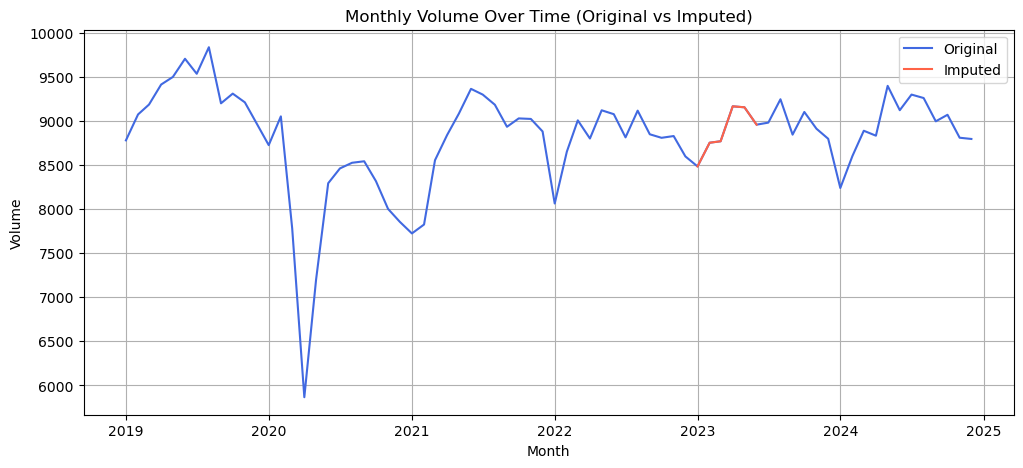

In [19]:
plt.figure(figsize=(12, 5))

plt.plot(combined_df.loc['2019':], label="Original", color="royalblue")

# Plot imputed data
plt.plot(reconstructed_df, label="Imputed", color="tomato")

plt.title("Monthly Volume Over Time (Original vs Imputed)")
plt.xlabel("Month")
plt.ylabel("Volume")
plt.legend()
plt.grid(True)
plt.show()

The imputed values appear to blend in fairly well with the rest of the time series, following a smooth trend and consistent seasonal pattern.  
While visual inspection gives a good first impression, it's important to note that **this might not always be sufficient**.

# So what data is this?